# RBL-4 Pilot Analysis (Week 7)
**Group:** SE1916-G2 · **Owner:** MS — Nguyen Le Thuan (SE190305)

Descriptive statistics of the Week-7 pilot: scenario distribution per arm/type and the edge-case histogram (RBL-4 §7.3). Statistical inference lives in `full_analysis.ipynb`; this notebook is descriptive only.

Data: `results/raw/scenarios.csv`, `results/raw/coverage.csv`, `results/raw/*_kills.csv` (pilot ran on the full compilable mutant catalog, N=133 — see `notes.md`).

In [1]:
import glob, json, os
import pandas as pd
import matplotlib.pyplot as plt

# works both when executed from repo root (nbclient) and when opened from results/ in Jupyter
RAW = os.path.join('..', 'results', 'raw') if os.path.basename(os.getcwd()) == 'results' else os.path.join('results', 'raw')
EDGE = {'negative', 'boundary', 'errorcode'}
pd.set_option('display.width', 160)


## 1. Scenario counts per arm × type

In [2]:
sc = pd.read_csv(os.path.join(RAW, 'scenarios.csv'))
sc.pivot_table(index='arm', columns='type', values='count', aggfunc='sum', fill_value=0)

type,boundary,errorcode,negative,positive
arm,,,,
llm,103,44,70,78
manual,55,37,49,56


## 2. Endpoint coverage per arm (RQ1 raw view)

In [3]:
cov = pd.read_csv(os.path.join(RAW, 'coverage.csv'))
cov.pivot_table(index='sut', columns='arm', values='coverage_pct')

arm,llm,manual
sut,,
features,100.0,100.0
ncs,100.0,100.0
scs,100.0,100.0


## 3. Histogram — per-endpoint edge-case distribution (LLM vs Manual)

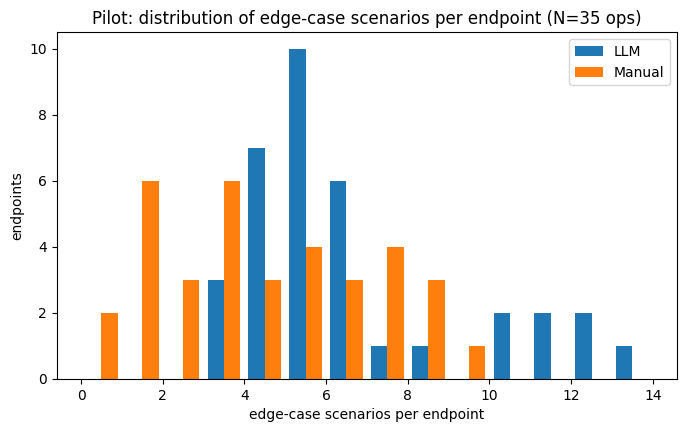

arm,llm,manual
count,35.000000,35.000000
mean,6.200000,4.028571
std,2.826347,2.595083
min,3.000000,0.000000
25%,4.000000,2.000000
50%,5.000000,4.000000
75%,6.500000,6.000000
max,13.000000,9.000000


In [4]:
edge = sc[sc['type'].isin(EDGE) & sc['arm'].isin(['llm','manual'])]
per_op = edge.groupby(['sut','op','arm'])['count'].sum().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8,4.5))
bins = range(0, int(per_op.values.max())+2)
ax.hist([per_op['llm'], per_op['manual']], bins=bins, label=['LLM','Manual'])
ax.set_title('Pilot: distribution of edge-case scenarios per endpoint (N=35 ops)')
ax.set_xlabel('edge-case scenarios per endpoint'); ax.set_ylabel('endpoints'); ax.legend()
plt.show()
per_op.describe()

## 4. Pilot mutation-kill counts (descriptive)

In [5]:
frames = []
for p in glob.glob(os.path.join(RAW, '*_kills.csv')):
    d = pd.read_csv(p); d['sut'] = os.path.basename(p).replace('_kills.csv',''); frames.append(d)
kills = pd.concat(frames, ignore_index=True)
print('mutants per SUT:', kills[kills.arm=='llm'].groupby('sut').size().to_dict())
kills.groupby('arm')['killed'].agg(['sum','count','mean']).rename(columns={'mean':'recall'})

mutants per SUT: {'features': 4, 'ncs': 70, 'scs': 59}


,sum,count,recall
arm,,,
evomaster,18,133,0.135338
llm,9,133,0.067669
manual,9,133,0.067669


### Pilot observations (descriptive, pre-registered caveats apply)
- LLM covers all endpoints; LLM produces more edge-case scenarios per endpoint than Manual.
- LLM and Manual kill vectors are **identical** on all mutants — the pre-registered "lenient oracle" threat (proposal §7): both arms assert existence/status, not values, so they are structurally blind to silent arithmetic mutants. Reported as a finding, not patched (no HARKing).